In [3]:
from google.colab import drive
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Montar Drive
drive.mount('/content/drive')

# 2. Rutas directas (Arquitectura definida)
path_raw = '/content/drive/MyDrive/MIA_Tesis_Ecuacalcios/01_Datos/Crudos_Anuales/'

# 3. Consolidación de archivos XLS
archivos = [f for f in os.listdir(path_raw) if f.lower().endswith(('.xls', '.xlsx'))]
archivos.sort()

print(f"📦 Cargando {len(archivos)} archivos de ventas...")
df_list = [pd.read_excel(os.path.join(path_raw, f)) for f in archivos]
df_master = pd.concat(df_list, ignore_index=True)

# Filtro preventivo: Producto 56 (Sulfato de Calcio)
df_p56 = df_master[df_master['codart'] == 56].copy()

print(f"✅ Registros de Sulfato de Calcio listos para análisis: {len(df_p56)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Cargando 8 archivos de ventas...
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
WARNING *** file size (5753867) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
WARNING *** file size (5877119) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
WARNING *** file size (3945945) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT 

In [4]:
# Definición de diccionarios geográficos (Basado en el agro de Ecuador)
keywords_sierra = ['IBARRA', 'TULCAN', 'QUITO', 'CARCHI', 'IMBABURA', 'PICHINCHA', 'CAYAMBE', 'OTAVALO', 'SAN GABRIEL', 'BOLIVAR']
keywords_costa = ['GUAYAQUIL', 'QUEVEDO', 'MILAGRO', 'MANABI', 'GUAYAS', 'LOS RIOS', 'MACHALA', 'SANTO DOMINGO', 'BABAHOYO']

def determinar_region(texto):
    if pd.isna(texto): return 'Sin Dirección'
    texto = str(texto).upper()
    if any(key in texto for key in keywords_sierra):
        return 'SIERRA NORTE / CENTRAL'
    elif any(key in texto for key in keywords_costa):
        return 'COSTA / CUENCA BAJA'
    return 'OTRA ZONA'

# Asumiendo que la columna de direcciones es la primera (índice 0)
col_direccion = df_master.columns[0]
df_p56['Region'] = df_p56[col_direccion].apply(determinar_region)

# Resumen de resultados
analisis_geo = df_p56['Region'].value_counts(normalize=True) * 100
print("--- RESULTADO DEL ANÁLISIS GEOGRÁFICO ---")
print(analisis_geo)

--- RESULTADO DEL ANÁLISIS GEOGRÁFICO ---
Region
OTRA ZONA                 87.384717
SIERRA NORTE / CENTRAL    11.791831
COSTA / CUENCA BAJA        0.823452
Name: proportion, dtype: float64


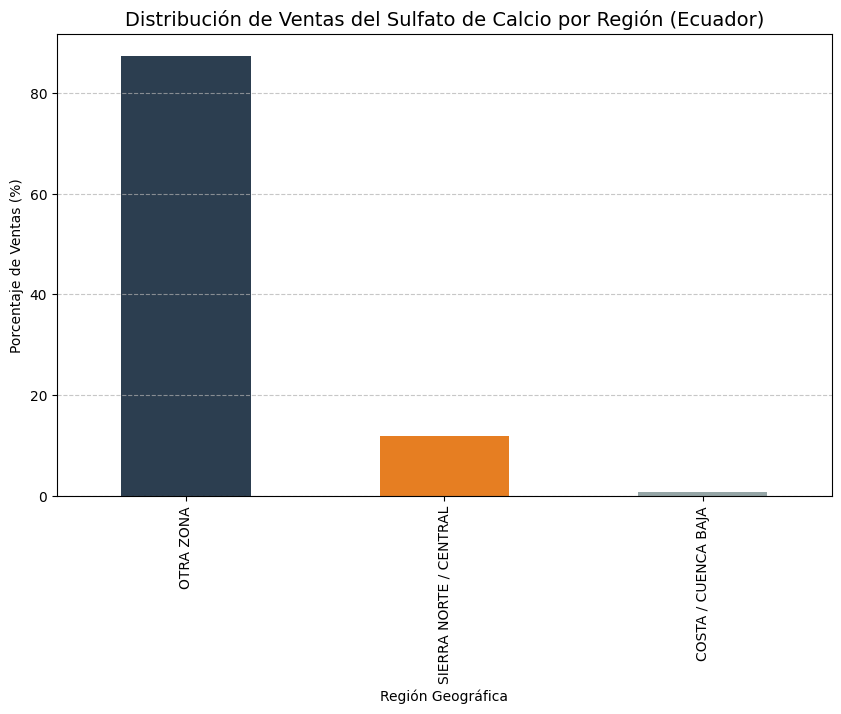


--- TOP 10 UBICACIONES CON MAYOR DEMANDA ---
direc1_a
PANAMERICANA NORTE KM 14 1/2 Y JOSE VITERI                   321
TABACUNDO                                                    320
LOS CEDROS OE 2-172 Y REAL AUDIENCIA                         231
KENNEDY, PIO JARAMILLO ALVARADO 752 Y CAPITAN RAMON BORJA    217
CAYAMBE                                                      148
ANGOSTURA E 14-51 E IBERIA                                   135
CALLE C S/N Y CALLE A                                        107
YARUQUÍ                                                       86
PANAMERICANA NORTE KM 16                                      70
LA VANZADA - CAMINO VIEJO NO. 700 MACHACHI                    44
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(10, 6))
analisis_geo.plot(kind='bar', color=['#2c3e50', '#e67e22', '#95a5a6'])
plt.title("Distribución de Ventas del Sulfato de Calcio por Región (Ecuador)", fontsize=14)
plt.ylabel("Porcentaje de Ventas (%)")
plt.xlabel("Región Geográfica")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Listado de las 10 ciudades con más ventas reales
print("\n--- TOP 10 UBICACIONES CON MAYOR DEMANDA ---")
print(df_p56[col_direccion].str.upper().value_counts().head(10))